Please upload your CSV file.


Saving my version of Strong Cesium gaussian three curves - Sheet1 (10).csv to my version of Strong Cesium gaussian three curves - Sheet1 (10) (7).csv
File uploaded: my version of Strong Cesium gaussian three curves - Sheet1 (10) (7).csv
Columns in the file: ['channel_18_deg', '18_degrees', 'channel_20_deg', '20_degrees', 'channel_25_deg', '25_degrees', 'channel_30_deg', '30_degrees', 'channel_40_deg', '40_degrees', 'channel_50_deg', '50_degrees', 'channel_60_deg', '60_degrees', 'channel_70_deg', '70_degrees', 'channel_80_deg', '80_degrees', 'channel_90_deg', '90_degrees', 'channel_100_deg', '100_degrees', 'channel_110_deg', '110_degrees', 'channel_0_deg_no_scatter', '0_deg_no_scatter', 'channel_0_deg_scatter', '0_deg_scatter', 'Unnamed: 28', 'channel_0_deg(entire)', '0_deg_no_scatter(entire)', '0° ( Scatter)_entire', 'Unnamed: 32', 'Large Aluminum', 'theta (degrees)', 'Y(theta)', 'sigma_Y(theta)', 'dσ/dΩ (Experimental)', 'sigma_dσ/dΩ (Experimental)', 'dσ/dΩ (K_N)', 'dσ/dΩ (Thomson )', 

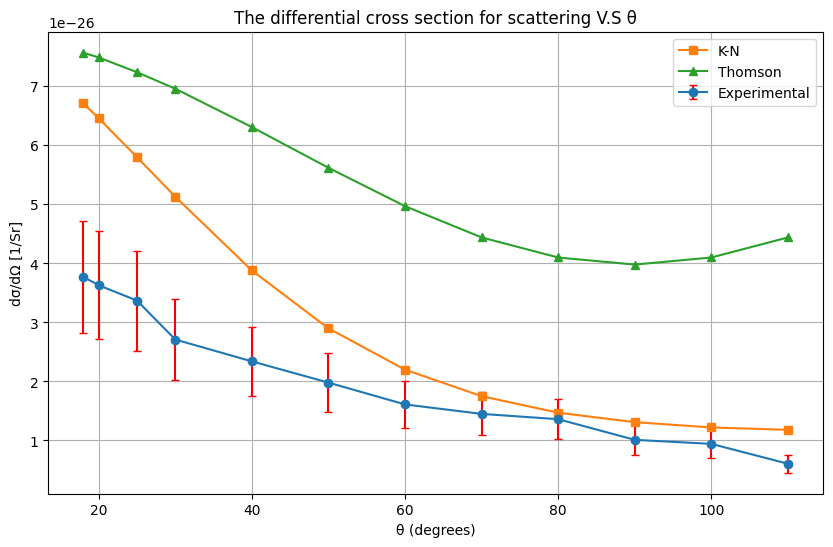

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import files

# Upload the CSV file
print("Please upload your CSV file.")
uploaded = files.upload()

# Read the CSV file into a pandas DataFrame
for filename in uploaded.keys():
    print(f"File uploaded: {filename}")
    data = pd.read_csv(filename)

# Check the structure of the file
print("Columns in the file:", data.columns.tolist())

# Ensure the file has the expected columns
required_columns = [
    'theta (degrees)',
    'dσ/dΩ (Experimental)',
    'sigma_dσ/dΩ (Experimental)',
    'dσ/dΩ (K_N)',
    'dσ/dΩ (Thomson )'
]
if not all(col in data.columns for col in required_columns):
    raise ValueError(f"The CSV file must contain the following columns: {required_columns}")

# Extract and clean the data
theta = pd.to_numeric(data['theta (degrees)'], errors='coerce')
curve1 = pd.to_numeric(data['dσ/dΩ (Experimental)'], errors='coerce')
sigma_curve1 = pd.to_numeric(data['sigma_dσ/dΩ (Experimental)'], errors='coerce')
curve2 = pd.to_numeric(data['dσ/dΩ (K_N)'], errors='coerce')
curve3 = pd.to_numeric(data['dσ/dΩ (Thomson )'], errors='coerce')

# Drop rows with NaN values after conversion
cleaned_data = pd.DataFrame({
    'theta': theta,
    'curve1': curve1,
    'sigma_curve1': sigma_curve1,
    'curve2': curve2,
    'curve3': curve3
}).dropna()

# Extract the cleaned data for plotting
theta_cleaned = cleaned_data['theta']
curve1_cleaned = cleaned_data['curve1']
sigma_curve1_cleaned = cleaned_data['sigma_curve1']
curve2_cleaned = cleaned_data['curve2']
curve3_cleaned = cleaned_data['curve3']

# Plot the data
plt.figure(figsize=(10, 6))

# Add experimental data with error bars and connect the points with a line
plt.errorbar(
    theta_cleaned,
    curve1_cleaned,
    yerr=sigma_curve1_cleaned,
    fmt='-o',  # 'o' for circular markers, '-' for line
    label='Experimental',
    ecolor='red',
    capsize=3
)

# Plot K-N and Thomson curves
plt.plot(theta_cleaned, curve2_cleaned, label='K-N', marker='s', linestyle='-')
plt.plot(theta_cleaned, curve3_cleaned, label='Thomson', marker='^', linestyle='-')

# Add labels, title, legend, and grid
plt.xlabel('θ (degrees)')
plt.ylabel('dσ/dΩ [1/Sr]')
plt.title('The differential cross section for scattering V.S θ')
plt.legend()
plt.grid(True)
plt.show()